In [2]:
import pandas as pd
import folium
from folium.features import GeoJson, GeoJsonTooltip
import plotly.express as px
import warnings
import requests
warnings.filterwarnings("ignore")

In [17]:

# List of years
years = [2019, 2020, 2021, 2022, 2023]

# Load the csv file
#df = pd.read_csv('Data/merged/merged_brfss_aqi_2023.csv')
#df.head()

# Load and combine
dfs = []
for year in years:
    file_path = f'Data/merged/merged_brfss_aqi_{year}.csv'
    df_year = pd.read_csv(file_path)
    df_year['year'] = year  
    dfs.append(df_year)

# Concatenate all years into one DataFrame
df_all_years = pd.concat(dfs, ignore_index=True)

# Preview
df_all_years.head()

df = df_all_years.copy()

# Renaming columns
df['_URBSTAT'] = df['_URBSTAT'].map({1.0: 'Urban', 2.0: 'Rural'})
df = df.rename(columns={'_URBSTAT': 'Area Type'})

df = df.rename(columns={'PM2.5 - Local Conditions_24-HR BLK AVG_PM25 24-hour 2024': 'PM2.5', 'Ozone_8-HR RUN AVG BEGIN HOUR_Ozone 8-hour 2015': 'Ozone'})



df.head()


,State,Area Type,SEXVAR,_SEX,_AGEG5YR,EDUCA,INCOME3,RENTHOM1,EMPLOY1,_STSTR,...,EXERANY2,AVEDRNK3,PRIMINS1,MEDCOST1,CHECKUP1,PERSDOC3,Year,Ozone,PM2.5,year
0,Alabama,Urban,NaN,0.0,3.0,2.0,21.0,7.0,NaN,11011,...,1.0,NaN,11.0,1.0,1.0,2.0,2019,0.041248,9.016707,2019
1,Alabama,Urban,NaN,0.0,0.0,2.0,22.0,7.0,NaN,11012,...,NaN,10.0,11.0,1.0,3.0,2.0,2019,0.041248,9.016707,2019
2,Alabama,Urban,NaN,0.0,0.0,2.0,21.0,7.0,NaN,11011,...,1.0,20.0,12.0,1.0,1.0,2.0,2019,0.041248,9.016707,2019
3,Alabama,Urban,NaN,NaN,NaN,2.0,2.0,7.0,NaN,11011,...,1.0,NaN,11.0,1.0,1.0,2.0,2019,0.041248,9.016707,2019
4,Alabama,Rural,NaN,0.0,0.0,2.0,22.0,5.0,NaN,11011,...,NaN,NaN,11.0,1.0,3.0,2.0,2019,0.041248,9.016707,2019


In [9]:
# This is just to get the FIPS data

# Download GeoJSON for U.S. states
url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json'
us_states = requests.get(url).json()
#us_states_pd = pd.DataFrame(us_states)
#us_states_pd.head()


In [23]:
# Keep only valid responses (1 = Yes, 2 = No)
asthma_clean = df.copy()
asthma_clean = asthma_clean[asthma_clean['ASTHMA3'].isin([1, 2])]
asthma_by_state = asthma_clean.groupby(['Area Type', 'Year', 'State', 'PM2.5', 'Ozone']).agg(
    asthma_yes=('ASTHMA3', lambda x: (x == 1).sum()),
    total=('ASTHMA3', 'count')
).reset_index()


asthma_by_state['asthma_prevalence'] = (asthma_by_state['asthma_yes'] / asthma_by_state['total']) * 100
asthma_by_state['asthma_prevalence'] = asthma_by_state['asthma_prevalence'].round(2) 

fips_to_state = {
    'Alabama': '01', 'Alaska' : '02', 'Arizona' : '04', 'Arkansas' : '05', 'California' : '06', 'Colorado' : '08', 
    'Connecticut' : '09', 'Delaware': '10', 'District of Columbia' : '11', 'Florida' : '12', 'Georgia' : '13', 
    'Hawaii' : '15', 'Idaho' : '16', 'Illinois' : '17', 'Indiana': '18', 'Iowa' : '19', 'Kansas' : '20', 'Louisiana' : '22', 
    'Maine' : '23', 'Maryland' : '24', 'Massachusetts' : '25', 'Michigan': '26', 'Minnesota' : '27', 'Mississippi' : '28', 
    'Missouri' : '29', 'Montana' : '30', 'Nebraska' : '31', 'Nevada' : '32',  'New Hampshire' : '33', 
    'New Jersey' : '34', 'New Mexico' : '35', 'New York' : '36', 'North Carolina' : '37', 'North Dakota' : '38',
    'Ohio': '39', 'Oklahoma' : '40', 'Oregon' : '41', 'Rhode Island' : '44', 'South Carolina' : '45', 'South Dakota' : '46', 
    'Tennessee' : '47', 'Texas': '48', 'Utah' : '49', 'Vermont' : '50', 'Virginia' : '51', 'Washington' : '53', 
    'West Virginia' : '54', 'Wisconsin' : '55','Wyoming': '56', 'Guam' : '66', 'Puerto Rico' : '72', 'Virgin Islands' : '78'
}

fips_to_abbr = {
    '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA', '08': 'CO', '09': 'CT',
    '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID', '17': 'IL',
    '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD',
    '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO', '30': 'MT', '31': 'NE',
    '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND',
    '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI', '45': 'SC', '46': 'SD',
    '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV',
    '55': 'WI', '56': 'WY'
}

# Apply the mapping
asthma_by_state['State Code'] = asthma_by_state['State'].map(fips_to_state)
asthma_by_state['State Abbr'] = asthma_by_state['State Code'].map(fips_to_abbr)
asthma_by_state = asthma_by_state.rename(columns={'PM2.5 - Local Conditions_24-HR BLK AVG_PM25 24-hour 2024': 'PM2.5', 'Ozone_8-HR RUN AVG BEGIN HOUR_Ozone 8-hour 2015': 'Ozone'})


asthma_by_state[ asthma_by_state['Year'] == 2023 ].head()


,Area Type,Year,State,PM2.5,Ozone,asthma_yes,total,asthma_prevalence,State Code,State Abbr
0,Rural,2023,Alabama,8.369426,0.043164,92,596,15.44,01,AL
1,Rural,2023,Alaska,4.545506,0.028154,268,1920,13.96,02,AK
2,Rural,2023,Arizona,7.319577,0.049037,143,884,16.18,04,AZ
3,Rural,2023,Arkansas,11.000141,0.041269,160,1301,12.30,05,AR
4,Rural,2023,California,7.660205,0.042838,28,231,12.12,06,CA


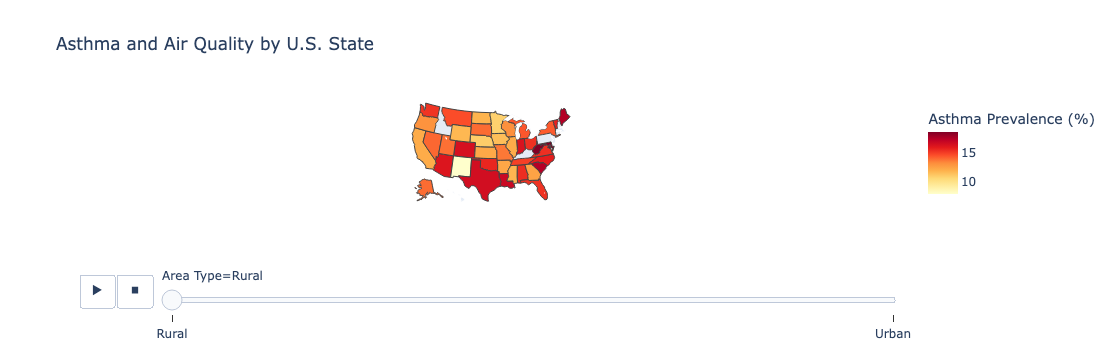

In [25]:
import plotly.express as px
fig = px.choropleth(
    asthma_by_state,
    animation_frame='Area Type',  # This creates the slider by year
    locations='State Abbr',
    locationmode='USA-states',
    color='asthma_prevalence',
    color_continuous_scale='YlOrRd',
    scope='usa',
    labels={'asthma_prevalence': 'Asthma Prevalence (%)'},
    hover_name='State',  
    hover_data={
        'PM2.5': True,
        'Ozone': True,
        'State': True ,
        'State Abbr': False
    },
    title='Asthma and Air Quality by U.S. State'
)

fig.show()

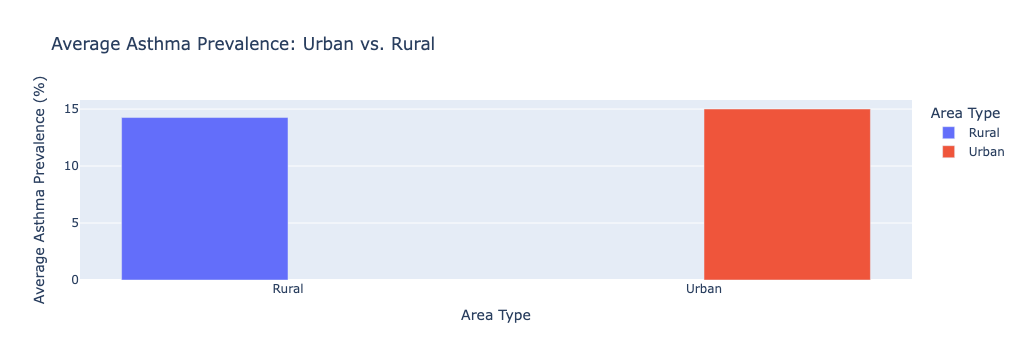

In [27]:
import plotly.express as px
import pandas as pd


# Grouping to get average asthma prevalence by Area Type
avg_df = asthma_by_state.groupby('Area Type', as_index=False)['asthma_prevalence'].mean()

# Plot bar chart
fig = px.bar(
    avg_df,
    x='Area Type',
    y='asthma_prevalence',
    color='Area Type',
    labels={'asthma_prevalence': 'Average Asthma Prevalence (%)'},
    title='Average Asthma Prevalence: Urban vs. Rural'
)

fig.show()

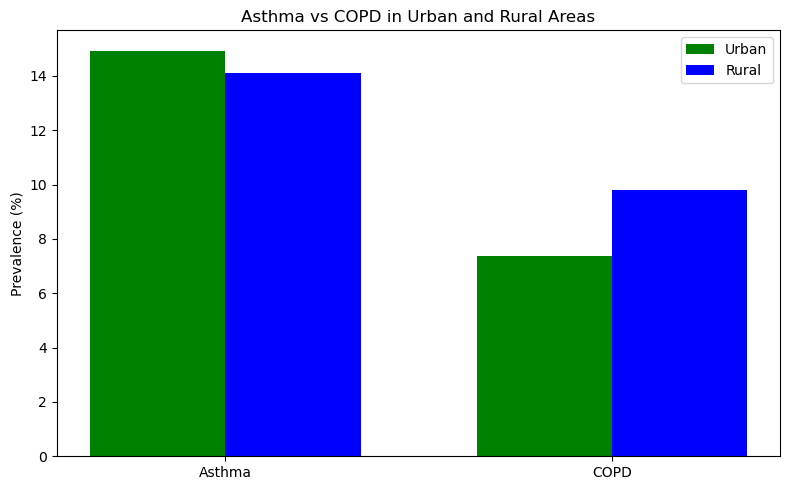

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_ur = df.copy()

#df_ur_clean = df[df['ASTHMA3'].isin([1, 2])]
df_ur = df_ur[['Area Type', 'ASTHMA3', 'CHCCOPD3']].dropna()

df_ur_agg = df_ur.groupby(['Area Type']).agg(
    asthma_yes=('ASTHMA3', lambda x: (x == 1).sum()),
    total_asthma=('ASTHMA3', 'count'),
    copd_yes=('CHCCOPD3', lambda x: (x == 1).sum()),
    total_copd=('CHCCOPD3', 'count')
).reset_index()


# Creating Asthma yes (i.e. 1) and copd yes (i.e. 1)
df_ur_agg['Asthma'] = (df_ur_agg['asthma_yes'] / df_ur_agg['total_asthma']) * 100
df_ur_agg['Asthma'] = df_ur_agg['Asthma'].round(2) 

df_ur_agg['COPD'] = (df_ur_agg['copd_yes'] / df_ur_agg['total_copd']) * 100
asthma_by_state['COPD'] = df_ur_agg['COPD'].round(2) 

df_ur_agg['Area Type']


# Extracting values
categories = ['Asthma', 'COPD']
urban_values = df_ur_agg[df_ur_agg['Area Type'] == 'Urban'][['Asthma', 'COPD']].values.flatten().astype(float)
rural_values = df_ur_agg[df_ur_agg['Area Type'] == 'Rural'][['Asthma', 'COPD']].values.flatten().astype(float)

# Setting bar width and positions
bar_width = 0.35
x = np.arange(len(categories))

# Creating bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - bar_width/2, urban_values, width=bar_width, color='green', label='Urban')
bars2 = ax.bar(x + bar_width/2, rural_values, width=bar_width, color='blue', label='Rural')

# Adding labels and title
ax.set_ylabel('Prevalence (%)')
ax.set_title('Asthma vs COPD in Urban and Rural Areas')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.show()

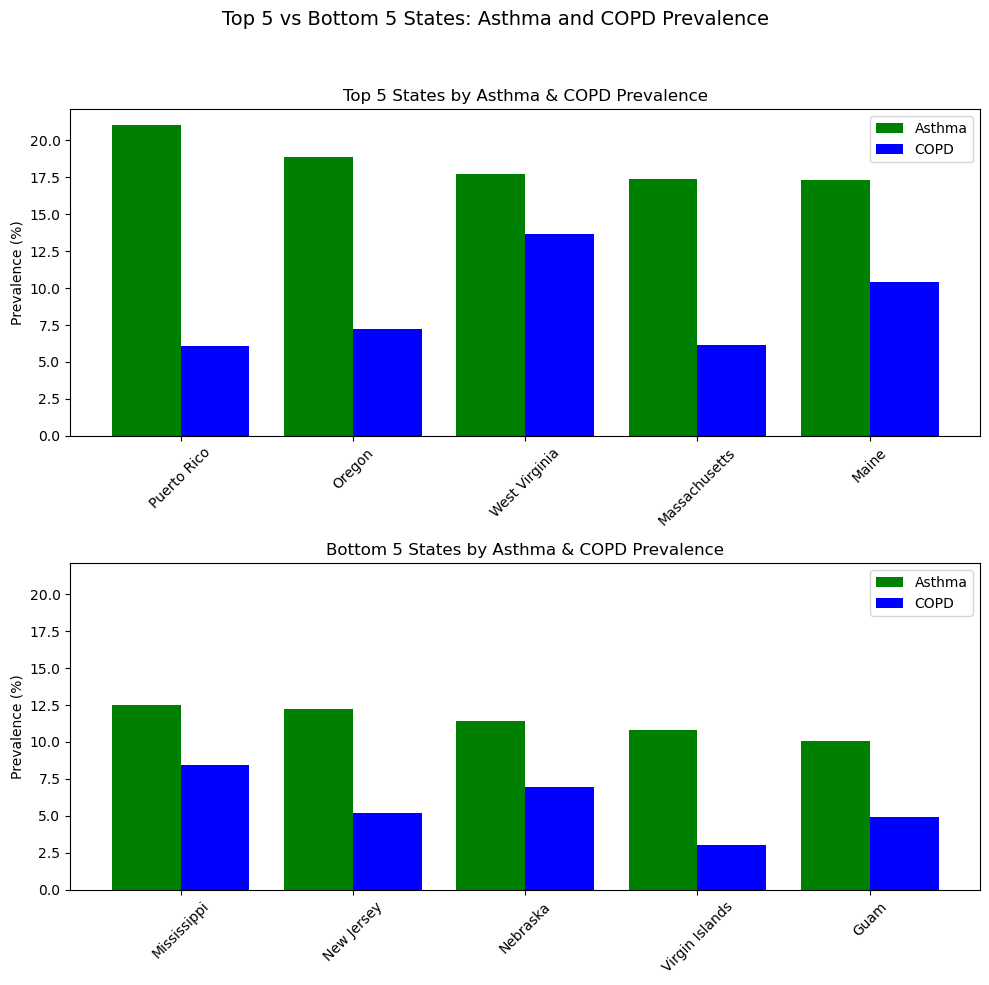

In [35]:

df_top_v_bottom_states = df.copy()

df_top_v_bottom_states = df_top_v_bottom_states[['State', 'ASTHMA3', 'CHCCOPD3']].dropna()

df_top_v_bottom_states_agg = df_top_v_bottom_states.groupby(['State']).agg(
    asthma_yes=('ASTHMA3', lambda x: (x == 1).sum()),
    total_asthma=('ASTHMA3', 'count'),
    copd_yes=('CHCCOPD3', lambda x: (x == 1).sum()),
    total_copd=('CHCCOPD3', 'count')
).reset_index()


# Creating Asthma yes (i.e. 1) and copd yes (i.e. 1)
df_top_v_bottom_states_agg['Asthma'] = (df_top_v_bottom_states_agg['asthma_yes'] / df_top_v_bottom_states_agg['total_asthma']) * 100
df_top_v_bottom_states_agg['Asthma'] = df_top_v_bottom_states_agg['Asthma'].round(2) 

df_top_v_bottom_states_agg['COPD'] = (df_top_v_bottom_states_agg['copd_yes'] / df_top_v_bottom_states_agg['total_copd']) * 100
df_top_v_bottom_states_agg['COPD'] = df_top_v_bottom_states_agg['COPD'].round(2) 

df_top_bottom = df_top_v_bottom_states_agg.copy()

df_sorted = df_top_bottom.sort_values(by='Asthma', ascending=False)
df_top5 = df_sorted.head(5)
df_bottom5 = df_sorted.tail(5)

# Create vertically stacked subplots
fig, axes = plt.subplots(nrows=2, figsize=(10, 10), sharey=True)

# Top 5 states chart
x1 = np.arange(len(df_top5))
axes[0].bar(x1 - 0.2, df_top5['Asthma'], width=0.4, label='Asthma', color='green')
axes[0].bar(x1 + 0.2, df_top5['COPD'], width=0.4, label='COPD', color='blue')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(df_top5['State'], rotation=45)
axes[0].set_title('Top 5 States by Asthma & COPD Prevalence')
axes[0].set_ylabel('Prevalence (%)')
axes[0].legend()

# Bottom 5 states chart
x2 = np.arange(len(df_bottom5))
axes[1].bar(x2 - 0.2, df_bottom5['Asthma'], width=0.4, label='Asthma', color='green')
axes[1].bar(x2 + 0.2, df_bottom5['COPD'], width=0.4, label='COPD', color='blue')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(df_bottom5['State'], rotation=45)
axes[1].set_title('Bottom 5 States by Asthma & COPD Prevalence')
axes[1].set_ylabel('Prevalence (%)')
axes[1].legend()

plt.suptitle('Top 5 vs Bottom 5 States: Asthma and COPD Prevalence', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
